# Random Forest Classification

Random forest to classify Wake, NREM, and REM from EEG frequency band features.

running on all 29 EXP1 mice, 86400 epochs each

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import sys
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score, cohen_kappa_score, matthews_corrcoef
from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

sys.path.insert(0, os.path.abspath('..'))
from pyecog2.convert_figshare_sleep_data import readbinary_dat
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10

1. Loading all EXP1 mice

extracting frequency band powers from the 401-bin power spectrum, mapping the numeric artifact states to the actual states and dropping any remaining null values.

In [18]:
def extract_power(power_spectra):
    """Sum power within each EEG frequency band (Hubbard & Franken 2020)."""
    freqs = np.arange(401) * 0.25
    bands = {
        'delta1': (0.75, 1.75), # slow delta, not sleep responsive
        'delta2': (2.5,  3.5), # fast delta, tracks sleep homeostasis
        'theta': (6.0,  9.0), # REM marker
        'sigma': (10.0, 15.0), # sleep spindles (NREM)
        'beta_lowgamma':(18.0, 45.0), # high frequency (wake)
    }
    result = {}
    for name, (lo, hi) in bands.items():
        index_lo = int(lo / 0.25)
        index_hi = int(hi / 0.25)
        result[name] = power_spectra[:, index_lo:index_hi].sum(axis=1)
    return result

In [19]:
def load_data(dat_file):
    scores, power_spectra, eeg_var, emg_var, _ = readbinary_dat(dat_file)

    # mapping artifact codes to states
    artifact_map = {'1': 'w', '2': 'n', '3': 'r'}
    states = np.array([artifact_map.get(s, s) for s in scores])

    bands = extract_power(power_spectra)

    df = pd.DataFrame({
        'state':       states,
        'eeg_variance': eeg_var,
        'emg_variance': emg_var,
        **bands
    })

    # logging power features (EEG power is log-normally distributed)
    power_cols = ['delta1', 'delta2', 'theta', 'sigma', 'beta_lowgamma',
                  'eeg_variance', 'emg_variance']
    df[power_cols] = np.log(df[power_cols].clip(lower=1e-30)) #to avoid -inf as well as log1p
    df['delta2_delta1_ratio'] = df['delta2'] - df['delta1']

    df = df[df['state'].isin(['w', 'n', 'r'])].reset_index(drop=True)
    return df

In [20]:
dat_files = sorted(glob.glob('data/M*EXP1.dat'))
print(f'Loading {len(dat_files)} EXP1 mice...')

mouse_dfs = {}
for dat_file in dat_files:
    mouse_id = os.path.splitext(os.path.basename(dat_file))[0]
    mouse_dfs[mouse_id] = load_data(dat_file)

print(f'Loaded {len(mouse_dfs)} mice')

Loading 29 EXP1 mice...
Loaded 29 mice


2. Features

| Feature | Description |
|---|---|
| delta1 | Slow delta (0.75–1.75 Hz) and logged |
| delta2 | Fast delta (2.5–3.5 Hz), homeostatic sleep marker |
| theta | Theta (6–9 Hz), higher in REM |
| sigma | Sigma (10–15 Hz), sleep spindles (for NREM) |
| beta_lowgamma | Beta/low-gamma (18–45 Hz), higher in Wake |
| eeg_variance | Total EEG signal variance |
| emg_variance | EMG variance, muscle activity so higher when awake |
| delta2_delta1_ratio | Sleep pressure |

In [13]:
FEATURES = ['delta1', 'delta2', 'theta', 'sigma', 'beta_lowgamma', 'eeg_variance', 'emg_variance', 'delta2_delta1_ratio']
LABEL = 'state'

# preview one mouse
list(mouse_dfs.values())[0][FEATURES + [LABEL]].head()

,delta1,delta2,theta,sigma,beta_lowgamma,eeg_variance,emg_variance,delta2_delta1_ratio,state
0,-11.036003,-9.640248,-9.441095,-10.525328,-9.498915,-19.243517,-21.908051,1.395755,w
1,-10.712376,-8.614235,-9.206966,-9.347326,-9.661184,-18.827913,-23.035021,2.098141,w
2,-10.915536,-9.111667,-9.756100,-10.122412,-9.549077,-19.264603,-23.332449,1.803869,w
3,-9.665816,-9.770272,-8.751550,-9.986262,-9.345723,-18.767168,-23.324778,-0.104456,n
4,-9.599375,-8.270100,-9.492494,-9.046444,-9.287940,-18.817999,-23.422405,1.329275,n


3. Leave-one-out CV

For each mouse we train on all the other mice and then predict on the mouse left out.
This tests whether the classifier generalises across animals.

class_weight='balanced' is used due to the imbalance in the distribution of sleep states (Wake ~55%, NREM ~40%, REM ~5%).

In [22]:
mouse_ids = list(mouse_dfs.keys())
results = []

all_y_true = []
all_y_pred = []


## Hyperparameter Tuning: Random Forest — n_estimators

Using a single fixed validation animal in M15EXP1 as it's a mid-range performer


In [ ]:
# fixed validation animal for RF tuning for efficiency and hardware limitations
# mid-range performer, not an outlier
VAL_MOUSE = 'M15EXP1'
train_mice_tune = [m for m in mouse_ids if m != VAL_MOUSE]
train_df_tune = pd.concat([mouse_dfs[m] for m in train_mice_tune], ignore_index=True)
val_df_tune = mouse_dfs[VAL_MOUSE]

X_train_tune = train_df_tune[FEATURES].values
y_train_tune = train_df_tune[LABEL].values
X_val_tune = val_df_tune[FEATURES].values
y_val_tune = val_df_tune[LABEL].values

n_estimators_grid = [50, 100, 200]
rf_tune_results = []

for n in n_estimators_grid:
    clf_tune = RandomForestClassifier(
        n_estimators=n, class_weight='balanced', n_jobs=-1, random_state=7
    )
    clf_tune.fit(X_train_tune, y_train_tune)
    bal_acc = balanced_accuracy_score(y_val_tune, clf_tune.predict(X_val_tune))
    rf_tune_results.append({'n_estimators': n, 'balanced_accuracy': bal_acc})
    print(f'n_estimators={n:>3d}: balanced accuracy = {bal_acc:.4f}')

rf_tune_df = pd.DataFrame(rf_tune_results)
best_n_rf = int(rf_tune_df.loc[rf_tune_df['balanced_accuracy'].idxmax(), 'n_estimators'])
print(f'\nBest n_estimators: {best_n_rf}')


n_estimators= 50: balanced accuracy = 0.7387
n_estimators=100: balanced accuracy = 0.7405
n_estimators=200: balanced accuracy = 0.7408

Best n_estimators: 200


In [ ]:
for test_mouse in mouse_ids:
    train_mice = [m for m in mouse_ids if m != test_mouse]

    train_df = pd.concat([mouse_dfs[m] for m in train_mice], ignore_index=True)
    test_df  = mouse_dfs[test_mouse]

    X_train = train_df[FEATURES].values
    y_train = train_df[LABEL].values
    X_test = test_df[FEATURES].values
    y_test = test_df[LABEL].values

    clf = RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        n_jobs=-1,
        random_state=7
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    bal_acc = balanced_accuracy_score(y_test, y_pred)
    results.append({'mouse': test_mouse, 'balanced_accuracy': bal_acc})
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

    print(f'{test_mouse}: balanced accuracy = {bal_acc:.3f}')

M10EXP1: balanced accuracy = 0.835
M11EXP1: balanced accuracy = 0.931
M12EXP1: balanced accuracy = 0.931
M13EXP1: balanced accuracy = 0.736
M14EXP1: balanced accuracy = 0.876
M15EXP1: balanced accuracy = 0.739
M16EXP1: balanced accuracy = 0.811
M17EXP1: balanced accuracy = 0.720
M18EXP1: balanced accuracy = 0.716
M19EXP1: balanced accuracy = 0.828
M1EXP1: balanced accuracy = 0.912
M20EXP1: balanced accuracy = 0.880
M21EXP1: balanced accuracy = 0.691
M22EXP1: balanced accuracy = 0.784
M23EXP1: balanced accuracy = 0.828
M24EXP1: balanced accuracy = 0.860
M25EXP1: balanced accuracy = 0.743
M26EXP1: balanced accuracy = 0.833
M27EXP1: balanced accuracy = 0.901
M28EXP1: balanced accuracy = 0.849
M29EXP1: balanced accuracy = 0.554
M2EXP1: balanced accuracy = 0.893
M3EXP1: balanced accuracy = 0.872
M4EXP1: balanced accuracy = 0.356
M5EXP1: balanced accuracy = 0.887
M6EXP1: balanced accuracy = 0.719
M7EXP1: balanced accuracy = 0.767
M8EXP1: balanced accuracy = 0.887
M9EXP1: balanced accuracy = 

In [24]:
results_df = pd.DataFrame(results)
print(f'\nMean balanced accuracy: {results_df["balanced_accuracy"].mean():.3f} +/- {results_df["balanced_accuracy"].std():.3f}')


Mean balanced accuracy: 0.797 +/- 0.121


## 4. Results / Analysis

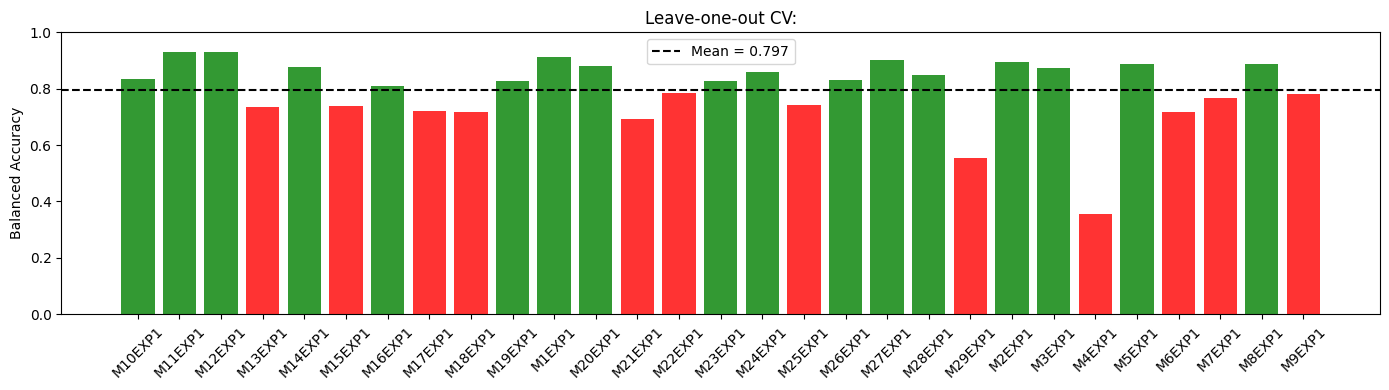

In [9]:
fig, ax = plt.subplots(figsize=(14, 4))
colors = ['red' if v < 0.8 else 'green' for v in results_df['balanced_accuracy']]
ax.bar(results_df['mouse'], results_df['balanced_accuracy'], color=colors, alpha=0.8)
ax.axhline(results_df['balanced_accuracy'].mean(), color='black', linestyle='--',
           label=f'Mean = {results_df["balanced_accuracy"].mean():.3f}')
ax.set_ylabel('Balanced Accuracy')
ax.set_title('Leave-one-out CV:')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

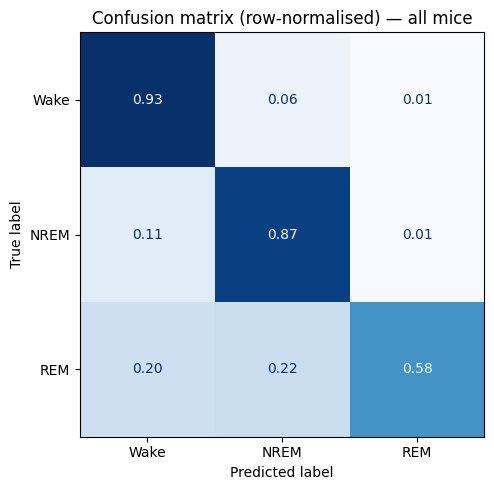

In [ ]:
# confusion matrix for all mice
labels = ['w', 'n', 'r']
label_names = ['Wake', 'NREM', 'REM']

cm = confusion_matrix(all_y_true, all_y_pred, labels=labels, normalize='true')

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')
ax.set_title('Confusion matrix (row-normalised, all mice)')
plt.tight_layout()
plt.show()

In [11]:
print(classification_report(all_y_true, all_y_pred, labels=['w', 'n', 'r'], target_names=['Wake', 'NREM', 'REM']))

              precision    recall  f1-score   support

        Wake       0.91      0.93      0.92   1421943
        NREM       0.88      0.87      0.88    948297
         REM       0.77      0.58      0.66    135360

    accuracy                           0.89   2505600
   macro avg       0.85      0.80      0.82   2505600
weighted avg       0.89      0.89      0.89   2505600



In [12]:
kappa = cohen_kappa_score(all_y_true, all_y_pred)
mcc = matthews_corrcoef(all_y_true, all_y_pred)

kappa, mcc

(0.7920765329077315, 0.7924961905221906)

## 5. Feature importance

Trained on all mice together to get stable importance estimates.

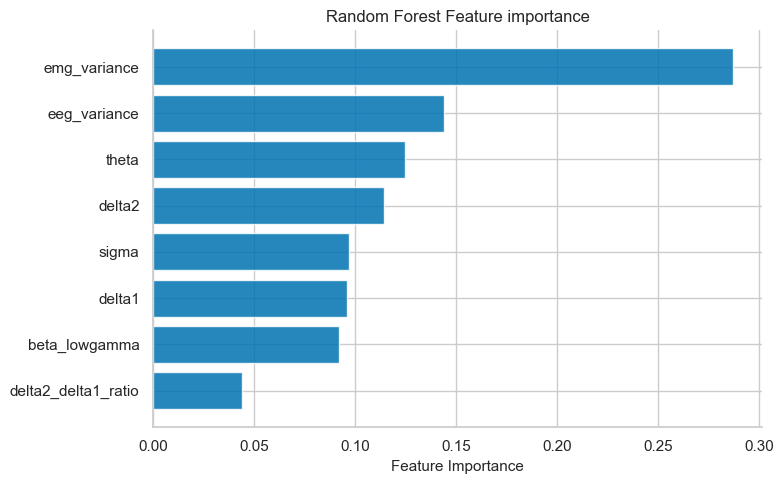

In [27]:
sns.set_theme(style="whitegrid")

plt.rcParams["font.family"] = "Arial"
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

all_df = pd.concat(mouse_dfs.values(), ignore_index=True)

clf_full = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    n_jobs=-1,
    random_state=7
)
clf_full.fit(all_df[FEATURES], all_df[LABEL])

importance_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': clf_full.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
blue = "#0072B2"

ax.barh(
    importance_df['feature'],
    importance_df['importance'],
    color=blue,
    alpha=0.85
)

ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest Feature importance')

sns.despine(ax=ax)

plt.tight_layout()
plt.show()

# XGBoost

XGBoost on the same 8 frequency band features and using leave-one-out CV

Class imbalance is handled by compute_sample_weight('balanced'), it's equivalent to class_weight='balanced' in RF

In [22]:
le = LabelEncoder().fit(['n', 'r', 'w'])  #n=0, r=1, w=2

## Hyperparameter Tuning: XGBoost random search

15-combination random search over n_estimators, max_depth, learning_rate, subsample, and colsample_bytree. Using M15EXP1, Uses GPU if available, if not then CPU.

X_train_tune, y_train_tune, X_val_tune, y_val_tune are reused from the RF tuning cell above.


In [11]:
# Detect GPU availability
try:
    import xgboost as xgb_lib
    _probe = XGBClassifier(tree_method='hist', device='cuda', n_estimators=1)
    _probe.fit([[0, 0]], [0])
    USE_DEVICE = 'cuda'
    print("GPU available")
except Exception:
    USE_DEVICE = 'cpu'

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree':[0.6, 0.8, 1.0]
}

GPU available


In [ ]:
from sklearn.model_selection import ParameterSampler

sampler = list(ParameterSampler(param_dist, n_iter=15, random_state=7))
xgb_tune_results = []

for params in sampler:
    xgb_tune = XGBClassifier(
        **params,
        tree_method='hist',
        device=USE_DEVICE,
        n_jobs=-1,
        random_state=7,
        eval_metric='mlogloss'
    )
    sw = compute_sample_weight('balanced', y_train_tune)
    xgb_tune.fit(X_train_tune, le.transform(y_train_tune), sample_weight=sw)
    y_pred_tune = le.inverse_transform(xgb_tune.predict(X_val_tune))
    bal_acc = balanced_accuracy_score(y_val_tune, y_pred_tune)
    xgb_tune_results.append({**params, 'balanced_accuracy': bal_acc})
    print(f"number_est={params['n_estimators']:>3d} depth={params['max_depth']}"
          f"learning rate={params['learning_rate']:.2f} sub={params['subsample']}"
          f"col={params['colsample_bytree']} -> {bal_acc:.4f}")

xgb_tune_df = pd.DataFrame(xgb_tune_results).sort_values('balanced_accuracy', ascending=False)
print('\nTop 5 XGBoost configurations:')
print(xgb_tune_df.head().to_string(index=False))

best_xgb_params = xgb_tune_df.iloc[0].drop('balanced_accuracy').to_dict()
best_xgb_params = {k: (int(v) if k in ('n_estimators', 'max_depth') else v)
                   for k, v in best_xgb_params.items()}
print(f'\nBest params: {best_xgb_params}')


number_est=100 depth=6 learning rate=0.20 sub=0.6 col=0.6 -> 0.8246
number_est=500 depth=8 learning rate=0.01 sub=0.6 col=0.8 -> 0.8232
number_est=300 depth=4 learning rate=0.10 sub=0.6 col=0.8 -> 0.8211
number_est=200 depth=8 learning rate=0.20 sub=0.8 col=0.8 -> 0.8231
number_est=300 depth=6 learning rate=0.10 sub=0.6 col=1.0 -> 0.8221
number_est=100 depth=8 learning rate=0.20 sub=0.6 col=0.6 -> 0.8235
number_est=300 depth=8 learning rate=0.05 sub=1.0 col=0.8 -> 0.8245
number_est=200 depth=6 learning rate=0.05 sub=0.8 col=0.6 -> 0.8225
number_est=300 depth=8 learning rate=0.20 sub=0.8 col=1.0 -> 0.8176
number_est=200 depth=4 learning rate=0.10 sub=0.8 col=0.8 -> 0.8201
number_est=500 depth=4 learning rate=0.01 sub=1.0 col=0.8 -> 0.8151
number_est=500 depth=4 learning rate=0.20 sub=0.8 col=1.0 -> 0.8231
number_est=500 depth=4 learning rate=0.10 sub=0.8 col=0.6 -> 0.8221
number_est=100 depth=4 learning rate=0.20 sub=1.0 col=0.8 -> 0.8208
number_est=300 depth=6 learning rate=0.05 sub=1.

In [23]:
mouse_ids = list(mouse_dfs.keys())
xgb_results = []
xgb_all_y_true = []
xgb_all_y_pred = []

In [ ]:
for test_mouse in mouse_ids:
    train_mice = [m for m in mouse_ids if m != test_mouse]

    train_df = pd.concat([mouse_dfs[m] for m in train_mice], ignore_index=True)
    test_df  = mouse_dfs[test_mouse]

    X_train = train_df[FEATURES].values
    y_train = train_df[LABEL].values
    X_test  = test_df[FEATURES].values
    y_test  = test_df[LABEL].values

    sample_weights = compute_sample_weight('balanced', y_train)

    xgb = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1,
        random_state=7,
        eval_metric='mlogloss'
    )
    xgb.fit(X_train, le.transform(y_train), sample_weight=sample_weights)
    y_pred = le.inverse_transform(xgb.predict(X_test))

    bal_acc = balanced_accuracy_score(y_test, y_pred)
    xgb_results.append({'mouse': test_mouse, 'balanced_accuracy': bal_acc})
    xgb_all_y_true.extend(y_test)
    xgb_all_y_pred.extend(y_pred)

    print(f'{test_mouse}: balanced accuracy = {bal_acc:.3f}')

M10EXP1: balanced accuracy = 0.897
M11EXP1: balanced accuracy = 0.875
M12EXP1: balanced accuracy = 0.924
M13EXP1: balanced accuracy = 0.812
M14EXP1: balanced accuracy = 0.905
M15EXP1: balanced accuracy = 0.824
M16EXP1: balanced accuracy = 0.889
M17EXP1: balanced accuracy = 0.820
M18EXP1: balanced accuracy = 0.795
M19EXP1: balanced accuracy = 0.863
M1EXP1: balanced accuracy = 0.920
M20EXP1: balanced accuracy = 0.893
M21EXP1: balanced accuracy = 0.784
M22EXP1: balanced accuracy = 0.848
M23EXP1: balanced accuracy = 0.873
M24EXP1: balanced accuracy = 0.879
M25EXP1: balanced accuracy = 0.727
M26EXP1: balanced accuracy = 0.904
M27EXP1: balanced accuracy = 0.905
M28EXP1: balanced accuracy = 0.898
M29EXP1: balanced accuracy = 0.691
M2EXP1: balanced accuracy = 0.922
M3EXP1: balanced accuracy = 0.927
M4EXP1: balanced accuracy = 0.370
M5EXP1: balanced accuracy = 0.918
M6EXP1: balanced accuracy = 0.860
M7EXP1: balanced accuracy = 0.859
M8EXP1: balanced accuracy = 0.941
M9EXP1: balanced accuracy = 


XGBoost mean balanced accuracy: 0.849 ± 0.110


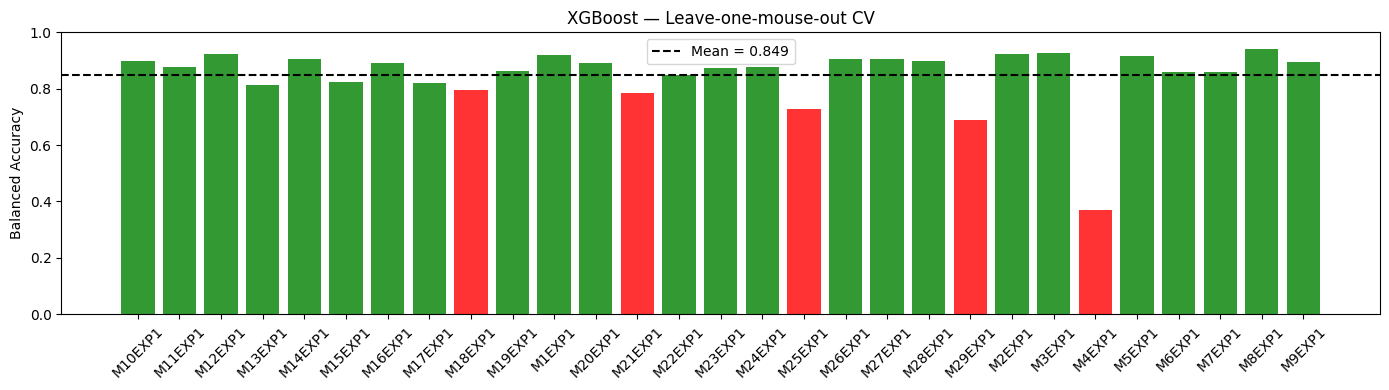

In [17]:
xgb_results_df = pd.DataFrame(xgb_results)
print(f'\nXGBoost mean balanced accuracy: {xgb_results_df["balanced_accuracy"].mean():.3f} +/- {xgb_results_df["balanced_accuracy"].std():.3f}')

fig, ax = plt.subplots(figsize=(14, 4))
colors = ['red' if v < 0.8 else 'green' for v in xgb_results_df['balanced_accuracy']]
ax.bar(xgb_results_df['mouse'], xgb_results_df['balanced_accuracy'], color=colors, alpha=0.8)
ax.axhline(xgb_results_df['balanced_accuracy'].mean(), color='black', linestyle='--',
           label=f'Mean = {xgb_results_df["balanced_accuracy"].mean():.3f}')
ax.set_ylabel('Balanced Accuracy')
ax.set_title('XGBoost — Leave-one-mouse-out CV')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

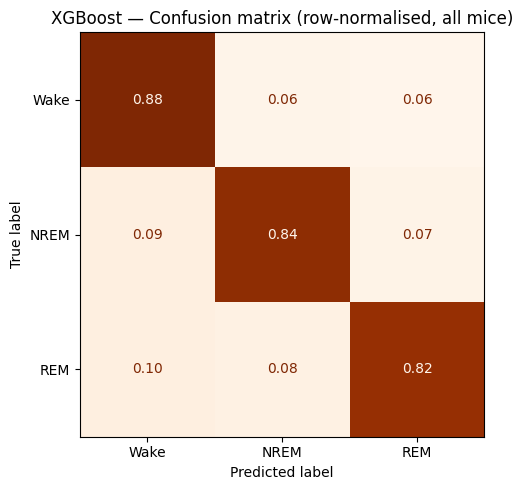

In [21]:
labels = ['w', 'n', 'r']
label_names = ['Wake', 'NREM', 'REM']

cm = confusion_matrix(xgb_all_y_true, xgb_all_y_pred, labels=labels, normalize='true')
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, colorbar=False, cmap='Oranges', values_format='.2f')
ax.set_title('XGBoost — Confusion matrix (row-normalised, all mice)')
plt.tight_layout()
plt.show()

In [20]:
print(classification_report(xgb_all_y_true, xgb_all_y_pred,
                            labels=labels, target_names=label_names))

kappa = cohen_kappa_score(xgb_all_y_true, xgb_all_y_pred)
mcc   = matthews_corrcoef(xgb_all_y_true, xgb_all_y_pred)
print(f"Cohen's kappa: {kappa:.4f}    MCC: {mcc:.4f}")

              precision    recall  f1-score   support

        Wake       0.93      0.88      0.90   1421943
        NREM       0.89      0.84      0.86    948297
         REM       0.43      0.82      0.57    135360

    accuracy                           0.86   2505600
   macro avg       0.75      0.85      0.78   2505600
weighted avg       0.89      0.86      0.87   2505600

Cohen's kappa: 0.7517    MCC: 0.7545


Feature importance

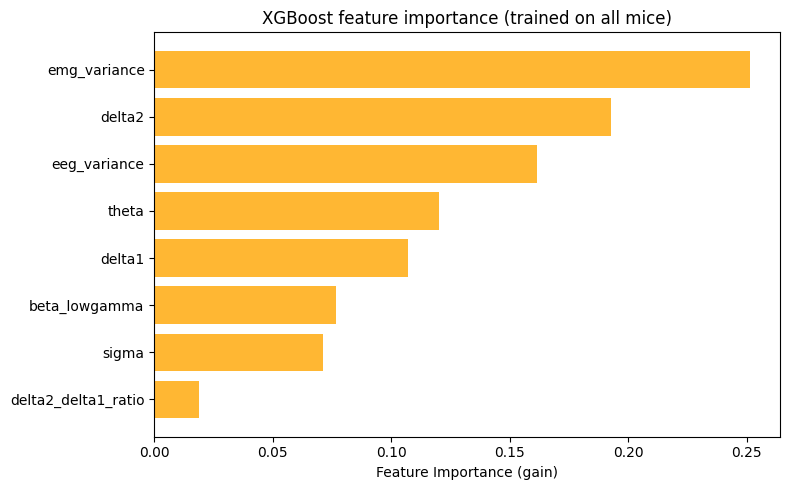

In [26]:
all_df = pd.concat(mouse_dfs.values(), ignore_index=True)
xgb_full = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
    n_jobs=-1, random_state=7, eval_metric='mlogloss'
)
w = compute_sample_weight('balanced', all_df[LABEL])
xgb_full.fit(all_df[FEATURES], le.transform(all_df[LABEL]), sample_weight=w)

xgb_importance_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': xgb_full.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(xgb_importance_df['feature'], xgb_importance_df['importance'], color='orange', alpha=0.8)
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('XGBoost feature importance (trained on all mice)')
plt.tight_layout()
plt.show()

In [28]:
# M4EXP1 performs worst across all classifiers, checking whether any features are unusual
# per-animal median for each feature
animal_medians = pd.DataFrame(
    {mouse: df[FEATURES].median() for mouse, df in mouse_dfs.items()}
).T

cohort_median = animal_medians.median()
cohort_mad = animal_medians.apply(lambda col: np.median(np.abs(col - col.median())))

deviations = (animal_medians.loc['M4EXP1'] - cohort_median) / cohort_mad
print("M4EXP1 deviation from cohort median (in MAD units):\n")
print(deviations.round(2).to_string())

M4EXP1 deviation from cohort median (in MAD units):

delta1                -1.00
delta2                 0.00
theta                 -0.62
sigma                 -1.03
beta_lowgamma         -1.08
eeg_variance          -0.36
emg_variance           5.07
delta2_delta1_ratio    1.09


In [29]:
# cohort mean BA with and without M4EXP1
excl = results_df[results_df['mouse'] != 'M4EXP1']['balanced_accuracy']
print(f"\nRF mean BA all 29: {results_df['balanced_accuracy'].mean():.3f}")
print(f"RF mean BA excl M4EXP1: {excl.mean():.3f}")


RF mean BA all 29: 0.797
RF mean BA excl M4EXP1: 0.813
